# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

In [27]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import confusion_matrix, accuracy_score

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?
   - We use them to map linear combinations to non-linear outputs or model complex relationships that linear models can't usually handle. Some asvantages include flexibility and non-linear pattern recognition.
2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.
   - They are effective loss functions because they utilize Maximum Likelihood Estimation to efficiently align predicted probabilities with real outcomes of the model.  
3. True or false, and explain: Logistic regression is a linear model.
   - True, because it uses a linear combination of input features to separate classes from a linear decision boundary.
4. True or false, and explain: Logistic regression cannot be used for classification.
   - False, because it is used for binary classification task such as calculating probability or applying a threshold.
5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?
   - No, becuase the coefficient represents the change in log-odds of the outcome for a 1 unit change in X. 
6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.
   - False, because you need feature engineering for logistic regression to perform well. Logistic regression still relies on a linear realtionship between features/log-odds, so the features must manually be created to capture the non-linear patterns.
7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.
   - False, because it can't entirely replace the OLS model. They do different tasks: OLS predicts continuous values and logistic regression predicts categories.

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.

2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?


2.1

In [4]:
df = pd.read_csv('./data/data.csv', sep=';')
cols = [
    'Debtor', 'Tuition fees up to date', 'Scholarship holder', 
    'Age at enrollment', 'Curricular units 1st sem (approved)', 'Target'
]
df = df[cols]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Target
0,0,1,0,20,0,Dropout
1,0,0,0,19,6,Graduate
2,0,0,0,19,0,Dropout
3,0,1,0,20,6,Graduate
4,0,1,0,45,5,Graduate


In [ ]:
# document missing values per column
df.isnull().sum()

Debtor                                 0
Tuition fees up to date                0
Scholarship holder                     0
Age at enrollment                      0
Curricular units 1st sem (approved)    0
Target                                 0
dtype: int64

In [12]:
df = df.dropna()

In [13]:
df['dropped_out'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

2.2

In [16]:
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
y = df['dropped_out']

log_model = LogisticRegression()
log_model.fit(X, y)

coeffs = pd.DataFrame({'Feature': X.columns, 'Coefficient': log_model.coef_[0]})
print(coeffs)

                   Feature  Coefficient
0                   Debtor     0.530625
1  Tuition fees up to date    -2.556542
2       Scholarship holder    -1.227442
3        Age at enrollment     0.049925


Positive coefficient = higher dropout probability
Negative coefficient = lower dropout probability

2.3

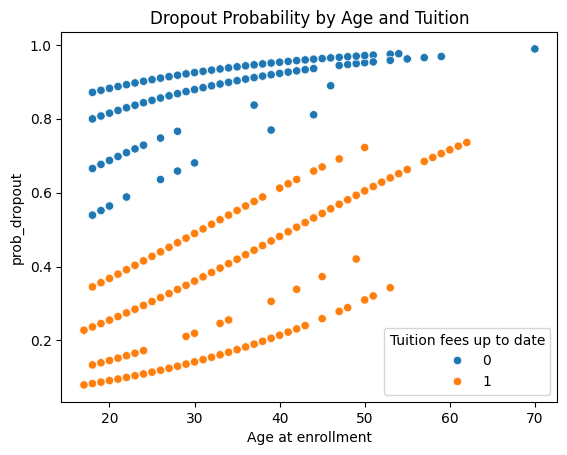

In [19]:
df['prob_dropout'] = log_model.predict_proba(X)[:, 1]

sns.scatterplot(data=df, x='Age at enrollment', y='prob_dropout', hue='Tuition fees up to date')
plt.title('Dropout Probability by Age and Tuition')
plt.show()

Being up to date on tuition reduces dropout probability the most for older students (between 30 and 50 years old).

In [21]:
avg_up_to_date = df[df['Tuition fees up to date'] == 1]['prob_dropout'].mean()
avg_not_up_to_date = df[df['Tuition fees up to date'] == 0]['prob_dropout'].mean()
print(f"Avg probability of dropping out (tuition up to date): {avg_up_to_date:.2f}")
print(f"Avg probability of dropping out (tuition not up to date): {avg_not_up_to_date:.2f}")
print(f"Difference: {avg_not_up_to_date - avg_up_to_date:.2f}")

Avg probability of dropping out (tuition up to date): 0.25
Avg probability of dropping out (tuition not up to date): 0.86
Difference: 0.61


2.4

In [24]:
y_pred = log_model.predict(X)

cm = confusion_matrix(y, y_pred)
acc = accuracy_score(y, y_pred)

print("Confusion Matrix:\n", cm)
print(f"Accuracy: {acc:.2%}")

Confusion Matrix:
 [[2841  162]
 [ 891  530]]
Accuracy: 76.20%


2.5

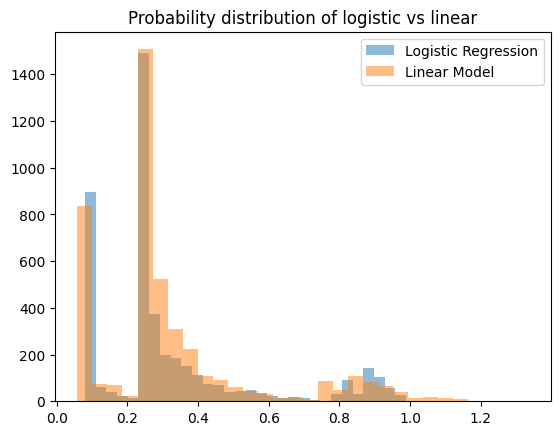

In [29]:
lin_model = LinearRegression()
lin_model.fit(X, y)
df['prob_linear'] = lin_model.predict(X)

plt.hist(df['prob_dropout'], bins=30, alpha=0.5, label='Logistic Regression')
plt.hist(df['prob_linear'], bins=30, alpha=0.5, label='Linear Model')
plt.legend()
plt.title('Probability distribution of logistic vs linear')
plt.show()

The distributions are very similar, however, the linear model shows a slightly higher probability of dropout.

2.6

Students most at risk of dropping out are those that are older, not as up to date on tuition, and not on scholarship. Some helpful interventions could be weekly check-ins with students, or providing mentors to keep track of their progress and guide them through their schooling.

2.7

In [31]:
X_multi = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y_multi = df['Target']

multi_model = LogisticRegression(solver='lbfgs', max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)
probs_multi = multi_model.predict_proba(X_multi)

print("Classes in model:", multi_model.classes_)
print("Classes actually predicted in hard classification:", np.unique(y_pred_multi))

cm_multi = confusion_matrix(y_multi, y_pred_multi, labels=multi_model.classes_)
print("Multinomial Confusion Matrix:\n", cm_multi)

Classes in model: ['Dropout' 'Enrolled' 'Graduate']
Classes actually predicted in hard classification: ['Dropout' 'Graduate']
Multinomial Confusion Matrix:
 [[1054    0  367]
 [ 280    0  514]
 [ 146    0 2063]]


**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics 
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class? 

3.1

In [78]:
df = pd.read_csv('./data/cirrhosis.csv')
cols = ['Bilirubin', 'Edema', 'Drug', 'Stage', 'Status']
df = df[cols]
#I handle missing values by dropping the rows that contain them
df = df.dropna()
df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [79]:
df['Survival'] = df['Status'].apply(lambda x: 1 if x in ['C', 'CL'] else 0)
df['Edema_idx'] = df['Edema'].map({'N': 0, 'S': 1, 'Y': 2})
df['Drug_idx'] = df['Drug'].map({'D-penicillamine': 1, 'Placebo': 0})

3.2

In [80]:
clean_df = df[['Bilirubin', 'Edema_idx', 'Drug_idx', 'Survival', 'Stage']].dropna().copy()

X = clean_df[['Edema_idx', 'Drug_idx', 'Bilirubin']]
y = clean_df['Survival']

log_reg = LogisticRegression()
log_reg.fit(X, y)

coeffs = pd.Series(log_reg.coef_[0], index=X.columns)
print("Coefficients:\n", coeffs)

Coefficients:
 Edema_idx   -0.915295
Drug_idx    -0.223469
Bilirubin   -0.348584
dtype: float64


Bc the coefficient for drug_idx is very close to zero, it does not improve survival. Higher bilirubin levels predict a lower survival rate and survival rate decreases as edema severity increases.

3.3

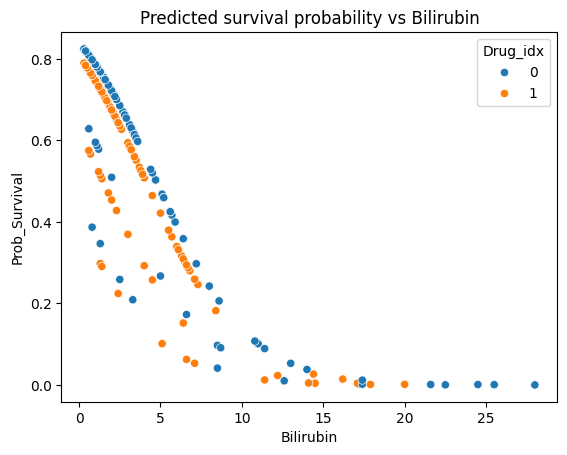

Avg survival (drug): 59.00%
Avg survival (placebo): 60.89%


In [81]:
clean_df['Prob_Survival'] = log_reg.predict_proba(X)[:, 1]

sns.scatterplot(data=clean_df, x='Bilirubin', y='Prob_Survival', hue='Drug_idx')
plt.title('Predicted survival probability vs Bilirubin')
plt.show()

avg_prob_drug = clean_df[clean_df['Drug_idx'] == 1]['Prob_Survival'].mean()
avg_prob_placebo = clean_df[clean_df['Drug_idx'] == 0]['Prob_Survival'].mean()
print(f"Avg survival (drug): {avg_prob_drug:.2%}")
print(f"Avg survival (placebo): {avg_prob_placebo:.2%}")

3.4

In [82]:
y_pred = log_reg.predict(X)

cm = confusion_matrix(y, y_pred)
accuracy = accuracy_score(y, y_pred)

print(f"Confusion Matrix:\n{cm}")
print(f"Accuracy: {accuracy:.2%}")

Confusion Matrix:
[[ 60  65]
 [ 14 173]]
Accuracy: 74.68%


3.5

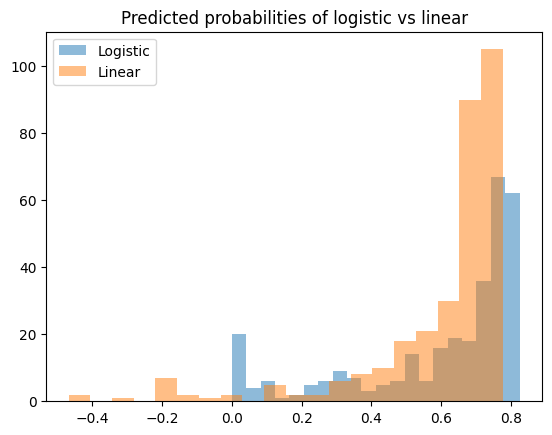

In [83]:
lin_model = LinearRegression()
lin_model.fit(X, y)
clean_df['Prob_Survival_Lin'] = lin_model.predict(X)

plt.hist(clean_df['Prob_Survival'], bins=20, alpha=0.5, label='Logistic')
plt.hist(clean_df['Prob_Survival_Lin'], bins=20, alpha=0.5, label='Linear')
plt.legend()
plt.title('Predicted probabilities of logistic vs linear')
plt.show()

The linear regression prediction is taller and is skewed left.

3.6

In [73]:
X_multi = clean_df[['Edema_idx', 'Bilirubin']]
y_multi = clean_df['Stage']

multi_model = LogisticRegression(max_iter=1000)
multi_model.fit(X_multi, y_multi)

y_pred_multi = multi_model.predict(X_multi)
probs_multi = multi_model.predict_proba(X_multi)

print("Classes predicted in hard classification:", np.unique(y_pred_multi))
print("Confusion matrix for stage:\n", confusion_matrix(y_multi, y_pred_multi))

print("\nFirst patient's probabilities for stage 1, 2, 3, and 4:")
print(probs_multi[0])

Classes predicted in hard classification: [3. 4.]
Confusion matrix for stage:
 [[ 0  0 11  1]
 [ 0  0 33  2]
 [ 0  0 44 12]
 [ 0  0 27 28]]

First patient's probabilities for stage 1, 2, 3, and 4:
[6.58085456e-06 4.24788599e-04 4.08443124e-02 9.58724318e-01]


**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio? 

4.1

The partial derivative of the prediction with respect to $x_k$ is the coefficient $b_k$. This means for every 1-unit change in the feature, the prediction changes by a constant amount of $b_k$ units regardless of the starting value.

4.2

The derivative is $\hat{p}(1 - \hat{p})b_k$, which means the change in predicted probability depends on the current value of $x$ and is not constant. This differs from the linear model because the feauture causes it to taper off as the probability approaches $0$ or $1$. The coefficient (divided by 4) is a good estimate of the change in probability when $\hat{p}$ is about $0.5$.

4.3

A one-unit change in $x_k$ increases the log odds ratio by $b_k$. This allows us to interpret the coefficients linearly, in terms of log-odds rather than raw probabilities.